# Phishing Email Detection — Cross-Source Ensemble
**Dataset:** MeAJOR | **Author:** [Your Name] | **Student ID:** [Your ID]

---

## Notebook Structure
| Section | Description |
|---------|-------------|
| 0 | Environment setup & global config |
| 1 | Data ingestion & preprocessing |
| 2 | Exploratory data analysis |
| 3 | Feature engineering |
| 4 | Model training with hyperparameter tuning |
| 5 | Ensemble methods |
| 6 | Evaluation & analysis |
| 7 | Leave-One-Source-Out (LOSO) generalisation test |
| 8 | Feature interpretability |
| 9 | Artifact persistence |

---

## 0. Environment Setup

In [ ]:
# Cell 0.1 — Install required libraries
!pip install --quiet \
    scikit-learn==1.6.0 \
    imbalanced-learn==0.12.3 \
    joblib==1.4.0 \
    beautifulsoup4>=4.13.0 \
    matplotlib \
    seaborn \
    scipy
print("All libraries installed.")

All libraries installed.


In [ ]:
# Cell 0.2 — Mount Google Drive and create versioned checkpoint directory
from google.colab import drive
import os, json, hashlib, joblib
from datetime import datetime

drive.mount("/content/drive")

# ── Global config ─────────────────────────────────────────────────────────────
RANDOM_STATE   = 42
BASE           = "/content/drive/MyDrive/phishing_project/"
RUN_ID         = datetime.now().strftime("%Y%m%d_%H%M%S")
CHECKPOINT_DIR = os.path.join(BASE, "checkpoints", f"v{RUN_ID}")

for sub in ["models", "metrics", "figures", "vectorisers", "logs"]:
    os.makedirs(os.path.join(CHECKPOINT_DIR, sub), exist_ok=True)
os.makedirs(BASE + 'checkpoints/figures/', exist_ok=True)
print(f"RANDOM_STATE   : {RANDOM_STATE}")
print(f"Checkpoint dir : {CHECKPOINT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RANDOM_STATE   : 42
Checkpoint dir : /content/drive/MyDrive/phishing_project/checkpoints/v20260411_180549


In [60]:
# Cell 0.3 — Artifact helper functions
import os, json, joblib
from datetime import datetime

def save_artifact(obj, filename, subdir, meta=None):
    path = os.path.join(CHECKPOINT_DIR, subdir, filename)
    joblib.dump(obj, path, compress=3)
    if meta:
        with open(path.replace('.pkl', '_meta.json'), 'w') as f:
            json.dump({**meta, 'saved_at': datetime.now().isoformat()}, f, indent=2)
    print(f"Saved -> {path}")
    return path

def load_artifact(filename, subdir):
    path = os.path.join(CHECKPOINT_DIR, subdir, filename)
    obj = joblib.load(path)
    print(f"Loaded <- {path}")
    return obj

print("Artifact helpers ready.")

Artifact helpers ready.
Checkpoint dir: /content/drive/MyDrive/phishing_project/checkpoints/final/


---
## 1. Data Ingestion & Preprocessing

### 1.1 Download & Load Dataset

In [ ]:
# Cell 1.1 — Download MeAJOR dataset from Zenodo with integrity check
import pandas as pd
import hashlib, requests, os

CSV_PATH = "/content/meajor_cleaned_preprocessed.csv"

if os.path.exists(CSV_PATH):
    os.remove(CSV_PATH)
    print("Removed cached file.")

print("Downloading from Zenodo...")
r = requests.get(
    "https://zenodo.org/records/18471483/files/meajor_cleaned_preprocessed.csv",
    stream=True
)
total      = int(r.headers.get("content-length", 0))
downloaded = 0
with open(CSV_PATH, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)
        downloaded += len(chunk)
        if total:
            print(f"\r  {downloaded/1024/1024:.1f} / {total/1024/1024:.1f} MB", end="")

with open(CSV_PATH, "rb") as f:
    DATASET_HASH = hashlib.md5(f.read()).hexdigest()

df_raw = pd.read_csv(CSV_PATH)

EXPECTED_ROWS = 108_685
assert df_raw.shape[0] == EXPECTED_ROWS, \
    f"Row count mismatch: got {df_raw.shape[0]}, expected {EXPECTED_ROWS}"

print(f"\nDataset loaded  : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"MD5             : {DATASET_HASH}")
print(f"Columns         : {list(df_raw.columns)}")
display(df_raw.head(3))

Removed cached file.

Dataset loaded  : 108,685 rows x 20 columns
MD5             : aa8f59e96787cbd696c0b650e5400dc9
Columns         : ['sender', 'sender_domain', 'receiver', 'receiver_domain', 'date', 'subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source', 'label']


,sender,sender_domain,receiver,receiver_domain,date,subject,content_types,body,urls,url_count,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,attachment_count,has_attachments,attachment_types,language,source,label
0,d66e9e64b006d6bca649f1c945129c42c43836872b2ead...,enron.com,35c5a9fb9fba3b8737ed7cef2a87e427a73db4fca85f6b...,enron.com,2001-06-29 09:37:04-05:00,[ORGANIZATION] failover plan.,text/plain,"Hi [NAME], \n\nTonight we are rolling out a n...",NaN,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0
1,0907d5c64598aa2639154ed4e1556be615669e40052a1f...,enron.com,aa2c35499eae5999bf6080453cc719a891da2bb0c3803d...,enron.com,2001-06-29 08:39:30-05:00,RE: Intranet Site,text/plain,"[NAME] r these new?\tIntranet Site\n\n[NAME],\...",http://eastpower.dev.corp.enron.com/summary/pj...,3.0,60.0,58.0,3.0,3.0,0.0,False,NaN,en,trec5,0.0
2,7c3201a5ff8c5985218f1e3f11e330dc0242bbd28c6c20...,enron.com,a736837579feb601fbf6c0657d3d93689774afa6491bb9...,enron.com;enron.com,2001-06-29 10:35:17-05:00,FW: [ORGANIZATION] Company information,text/plain,"[NAME]/[NAME],\n\nWe are currently trading und...",NaN,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0


### 1.2 Column Selection

We retain text features, URL-based structural features, and the label. Pure metadata (sender address, receiver, date) carries no generalizable signal and is dropped.

In [ ]:
# Cell 1.2 — Drop pure metadata; RETAIN URL structural features
df = df_raw.copy()

DROP_COLS = ["sender", "sender_domain", "receiver", "receiver_domain", "date"]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# Rename source -> source_id for clarity
if "source" in df.columns:
    df = df.rename(columns={"source": "source_id"})

print(f"Retained columns ({len(df.columns)}): {list(df.columns)}")
display(df.head(3))

Retained columns (15): ['subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source_id', 'label']


,subject,content_types,body,urls,url_count,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,attachment_count,has_attachments,attachment_types,language,source_id,label
0,[ORGANIZATION] failover plan.,text/plain,"Hi [NAME], \n\nTonight we are rolling out a n...",NaN,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0
1,RE: Intranet Site,text/plain,"[NAME] r these new?\tIntranet Site\n\n[NAME],\...",http://eastpower.dev.corp.enron.com/summary/pj...,3.0,60.0,58.0,3.0,3.0,0.0,False,NaN,en,trec5,0.0
2,FW: [ORGANIZATION] Company information,text/plain,"[NAME]/[NAME],\n\nWe are currently trading und...",NaN,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0


### 1.3 Null Imputation

In [ ]:
# Cell 1.3 — Impute missing values per column type
# Text columns → empty string
for col in ["subject", "body"]:
    if col in df.columns:
        df[col] = df[col].fillna("")

# Numeric URL features → 0 (no URLs present)
URL_NUM_COLS = ["url_count", "url_length_max", "url_length_avg",
                "url_subdom_max", "url_subdom_avg"]
for col in URL_NUM_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Categorical → 'unknown'
for col in ["content_types", "language", "urls"]:
    if col in df.columns:
        df[col] = df[col].fillna("unknown")

missing = df.isnull().sum()
remaining = missing[missing > 0]
if remaining.empty:
    print("No missing values remain.")
else:
    print("Remaining missing values:")
    display(remaining)

Remaining missing values:


,0
attachment_types,107019
source_id,1
label,1


### 1.4 Text Preprocessing Pipeline

Apply HTML stripping → lowercasing → punctuation/digit removal → tokenisation → stopword removal → lemmatisation.

In [ ]:
# Cell 1.4 — Download NLTK resources
import nltk
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)
print("NLTK resources ready.")

NLTK resources ready.


In [ ]:
# Cell 1.5 — Define and apply text preprocessing function
import re
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

STOP_WORDS  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in STOP_WORDS and len(w) > 1]
    return " ".join(tokens)

# Apply (2–5 min on 108k rows)
df['subject_processed'] = df['subject'].apply(preprocess_text)
df['body_processed']    = df['body'].apply(preprocess_text)

print("Text preprocessing applied.")
display(df[['subject', 'subject_processed', 'body', 'body_processed']].head(3))

/tmp/ipykernel_9786/3652502964.py:14: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a filename than HTML or XML.

If you meant to use Beautiful Soup to parse the contents of a file on disk, then something has gone wrong. You should open the file first, using code like this:

    filehandle = open(your filename)

You can then feed the open filehandle into Beautiful Soup instead of using the filename.

However, if you want to parse some data that happens to look like a filename, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
/tmp/ipykernel_9786/3652502964.py:14: XMLParsedAsHTM

Text preprocessing applied.


,subject,subject_processed,body,body_processed
0,[ORGANIZATION] failover plan.,organization failover plan,"Hi [NAME], \n\nTonight we are rolling out a n...",hi name tonight rolling new report currently n...
1,RE: Intranet Site,intranet site,"[NAME] r these new?\tIntranet Site\n\n[NAME],\...",name new intranet site name need link added or...
2,FW: [ORGANIZATION] Company information,fw organization company information,"[NAME]/[NAME],\n\nWe are currently trading und...",namename currently trading gtc spot contract o...


### 1.5 Combine Text Fields & Build Feature Matrix

In [ ]:
# Cell 1.6 — Combine subject + body into email_text; preserve URL features
df["email_text"] = (
    df["subject_processed"].astype(str) + " " +
    df["body_processed"].astype(str)
).str.strip()

# Drop rows with missing label
df = df.dropna(subset=['label']).reset_index(drop=True)

# Null-safety assertions
assert df["email_text"].isnull().sum() == 0, "Nulls in email_text!"
assert df["label"].isnull().sum()      == 0, "Nulls in label!"

# Clip URL numeric features to remove outlier noise
for col in URL_NUM_COLS:
    if col in df.columns:
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper)

print(f"Final shape : {df.shape}")
print(f"Columns     : {list(df.columns)}")
display(df.head(3))

Final shape : (108684, 18)
Columns     : ['subject', 'content_types', 'body', 'urls', 'url_count', 'url_length_max', 'url_length_avg', 'url_subdom_max', 'url_subdom_avg', 'attachment_count', 'has_attachments', 'attachment_types', 'language', 'source_id', 'label', 'subject_processed', 'body_processed', 'email_text']


,subject,content_types,body,urls,url_count,url_length_max,url_length_avg,url_subdom_max,url_subdom_avg,attachment_count,has_attachments,attachment_types,language,source_id,label,subject_processed,body_processed,email_text
0,[ORGANIZATION] failover plan.,text/plain,"Hi [NAME], \n\nTonight we are rolling out a n...",unknown,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0,organization failover plan,hi name tonight rolling new report currently n...,organization failover plan hi name tonight rol...
1,RE: Intranet Site,text/plain,"[NAME] r these new?\tIntranet Site\n\n[NAME],\...",http://eastpower.dev.corp.enron.com/summary/pj...,3.0,60.0,58.0,3.0,3.0,0.0,False,NaN,en,trec5,0.0,intranet site,name new intranet site name need link added or...,intranet site name new intranet site name need...
2,FW: [ORGANIZATION] Company information,text/plain,"[NAME]/[NAME],\n\nWe are currently trading und...",unknown,0.0,0.0,0.0,0.0,0.0,0.0,False,NaN,en,trec5,0.0,fw organization company information,namename currently trading gtc spot contract o...,fw organization company information namename c...


In [ ]:
# Cell 1.7 — Duplicate detection and removal
n_dups = df.duplicated(subset=["email_text"]).sum()
print(f"Exact duplicates found: {n_dups:,}")
if n_dups > 0:
    df = df.drop_duplicates(subset=["email_text"]).reset_index(drop=True)
    print(f"Duplicates removed. Remaining: {len(df):,}")
else:
    print("No duplicates — dataset is clean.")

Exact duplicates found: 5,344
Duplicates removed. Remaining: 103,340


---
## 2. Exploratory Data Analysis

### 2.1 Class Distribution

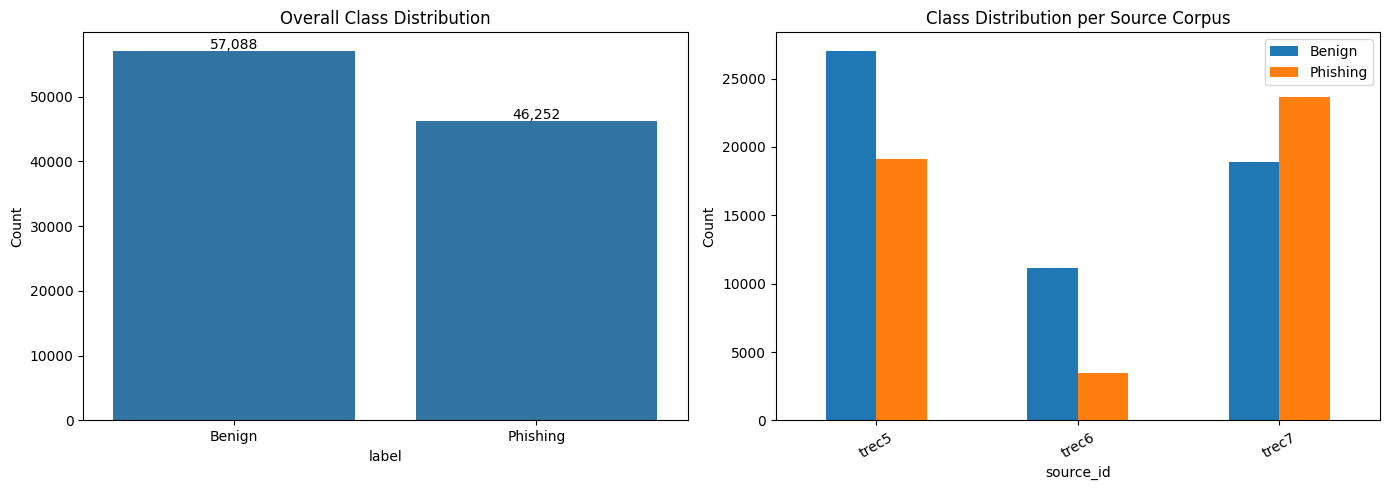

label
Benign      57088
Phishing    46252
Name: count, dtype: int64

Phishing ratio: 44.8%

Per-source breakdown:


,Benign,Phishing
source_id,,
trec5,27024,19108
trec6,11161,3488
trec7,18903,23656


In [ ]:
# Cell 2.1 — Overall and per-source class distribution
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
label_counts = df['label'].value_counts().rename({0.0: 'Benign', 1.0: 'Phishing'})
sns.barplot(x=label_counts.index, y=label_counts.values, ax=axes[0])
axes[0].set_title('Overall Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontsize=10)

# Per source
source_label = df.groupby(['source_id', 'label']).size().unstack(fill_value=0)
source_label.columns = ['Benign', 'Phishing']
source_label.plot(kind='bar', ax=axes[1])
axes[1].set_title('Class Distribution per Source Corpus')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(BASE + 'checkpoints/figures/class_distribution.png', dpi=150)
plt.show()

print(label_counts)
print(f"\nPhishing ratio: {label_counts['Phishing']/len(df)*100:.1f}%")
print("\nPer-source breakdown:")
display(source_label)

### 2.2 Email Length & URL Feature Analysis

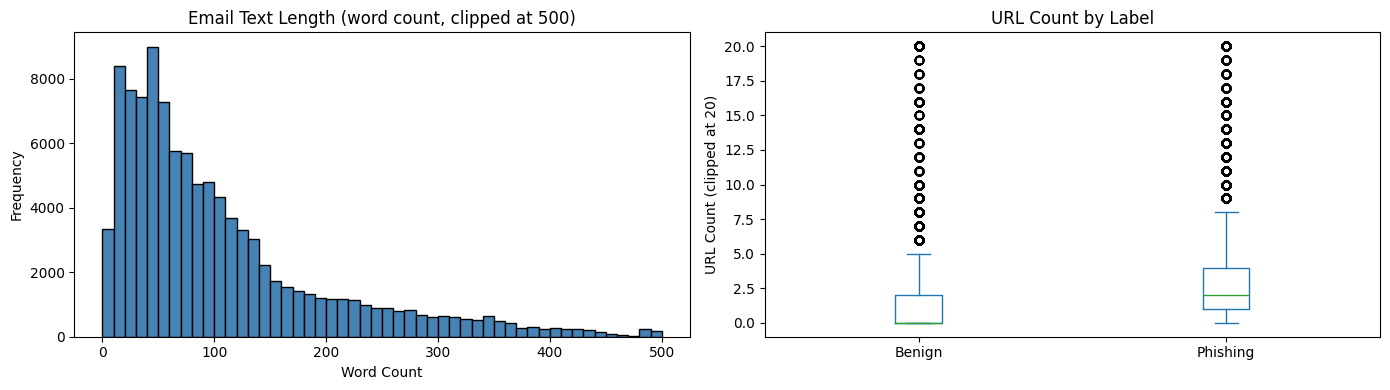

Text length statistics:
count    103340.0
mean        105.2
std          96.3
min           0.0
25%          38.0
50%          74.0
75%         136.0
max        1176.0
Name: text_length, dtype: float64

URL count statistics by label:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Benign,57088.0,2.45,8.09,0.0,0.0,0.0,2.0,57.0
Phishing,46252.0,3.82,7.58,0.0,1.0,2.0,4.0,57.0


In [ ]:
# Cell 2.2 — Text length distribution and URL feature statistics
df['text_length'] = df['email_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Text length histogram
axes[0].hist(df['text_length'].clip(upper=500), bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Email Text Length (word count, clipped at 500)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

# URL count by label
if 'url_count' in df.columns:
    url_by_label = df.groupby(df['label'].map({0.0: 'Benign', 1.0: 'Phishing'}))['url_count']
    url_by_label.apply(lambda x: x.clip(upper=20)).unstack().T.plot(
        kind='box', ax=axes[1]
    )
    axes[1].set_title('URL Count by Label')
    axes[1].set_ylabel('URL Count (clipped at 20)')

plt.tight_layout()
plt.savefig(BASE + 'checkpoints/figures/eda_distributions.png', dpi=150)
plt.show()

print("Text length statistics:")
print(df['text_length'].describe().round(1))
if 'url_count' in df.columns:
    print("\nURL count statistics by label:")
    display(df.groupby(df['label'].map({0.0:'Benign', 1.0:'Phishing'}))['url_count'].describe().round(2))

---
## 3. Feature Engineering
TF-IDF text features (20,000 vocabulary, unigrams to trigrams) are used as the feature matrix for all classifiers.

In [ ]:
# Cell 3.1 — Stratified train / validation / test split (60/20/20)
import numpy as np
from sklearn.model_selection import train_test_split

X_text = df['email_text']
y      = df['label'].astype(int)

# First split: 80% train+val, 20% test
X_tv, X_test_text, y_tv, y_test = train_test_split(
    X_text, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Second split: 75% of 80% = 60% train, 25% of 80% = 20% val
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=RANDOM_STATE, stratify=y_tv
)

print(f"Train : {len(X_train_text):,}  ({len(X_train_text)/len(df)*100:.0f}%)")
print(f"Val   : {len(X_val_text):,}  ({len(X_val_text)/len(df)*100:.0f}%)")
print(f"Test  : {len(X_test_text):,}  ({len(X_test_text)/len(df)*100:.0f}%)")

# Corresponding index arrays for URL features
train_idx = X_train_text.index
val_idx   = X_val_text.index
test_idx  = X_test_text.index

Train : 62,004  (60%)
Val   : 20,668  (20%)
Test  : 20,668  (20%)


In [ ]:
# Cell 3.2 — Fit TF-IDF on training set ONLY; transform val and test
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3),
    min_df=5,
    max_df=0.95,
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train_text)   # fit here only
X_val_tfidf   = tfidf.transform(X_val_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f"Vocabulary size : {len(tfidf.vocabulary_):,}")
print(f"Train TF-IDF    : {X_train_tfidf.shape}")
print(f"Val   TF-IDF    : {X_val_tfidf.shape}")
print(f"Test  TF-IDF    : {X_test_tfidf.shape}")

Vocabulary size : 20,000
Train TF-IDF    : (62004, 20000)
Val   TF-IDF    : (20668, 20000)
Test  TF-IDF    : (20668, 20000)


In [72]:
# Cell 3.3 — Feature matrix (TF-IDF only, 20,000 features)
X_train_hybrid = X_train_tfidf
X_test_hybrid  = X_test_tfidf
scaler         = None
print("Feature matrix ready (TF-IDF only, 20,000 features)")
print(f"Train: {X_train_hybrid.shape} | Test: {X_test_hybrid.shape}")

Feature matrix ready (TF-IDF only, 20,000 features)
Train: (62004, 20000) | Test: (20668, 20000)


---
## 4. Model Training with Hyperparameter Tuning

Each classifier is tuned using `RandomizedSearchCV` on the validation-aware training set. The validation set is used to select the best hyperparameters before any test-set evaluation.

In [ ]:
# Cell 4.1 — Logistic Regression with hyperparameter tuning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
import numpy as np

lr_param_dist = {
    'C'      : [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    'solver' : ['lbfgs', 'saga'],
    'max_iter': [500, 1000]
}

lr_base = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)

lr_search = RandomizedSearchCV(
    lr_base, lr_param_dist,
    n_iter=10, cv=3, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
lr_search.fit(X_train_hybrid, y_train)
lr = lr_search.best_estimator_

y_pred_lr = lr.predict(X_test_hybrid)

print(f"Best LR params : {lr_search.best_params_}")
print(f"Val F1 (macro) : {lr_search.best_score_:.4f}")
print("\nTest set results:")
print(classification_report(y_test, y_pred_lr, target_names=['Benign', 'Phishing'], digits=4))

Best LR params : {'solver': 'saga', 'max_iter': 500, 'C': 10.0}
Val F1 (macro) : 0.9750

Test set results:
              precision    recall  f1-score   support

      Benign     0.9821    0.9767    0.9794     11418
    Phishing     0.9714    0.9781    0.9747      9250

    accuracy                         0.9773     20668
   macro avg     0.9768    0.9774    0.9771     20668
weighted avg     0.9773    0.9773    0.9773     20668



In [ ]:
# Cell 4.2 — LinearSVC with hyperparameter tuning
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svc_param_dist = {
    'estimator__C'       : [0.01, 0.1, 0.5, 1.0, 5.0],
    'estimator__max_iter': [1000, 2000]
}

svc_base = CalibratedClassifierCV(
    LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)
)

svc_search = RandomizedSearchCV(
    svc_base, svc_param_dist,
    n_iter=8, cv=3, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
svc_search.fit(X_train_hybrid, y_train)
svc = svc_search.best_estimator_

y_pred_svc = svc.predict(X_test_hybrid)

print(f"Best SVC params : {svc_search.best_params_}")
print(f"Val F1 (macro)  : {svc_search.best_score_:.4f}")
print("\nTest set results:")
print(classification_report(y_test, y_pred_svc, target_names=['Benign', 'Phishing'], digits=4))

Best SVC params : {'estimator__max_iter': 2000, 'estimator__C': 1.0}
Val F1 (macro)  : 0.9756

Test set results:
              precision    recall  f1-score   support

      Benign     0.9815    0.9782    0.9798     11418
    Phishing     0.9732    0.9772    0.9752      9250

    accuracy                         0.9777     20668
   macro avg     0.9773    0.9777    0.9775     20668
weighted avg     0.9778    0.9777    0.9777     20668



In [ ]:
# Cell 4.3 — Multinomial Naive Bayes (ROS pipeline) — text-only features
# MNB requires non-negative inputs; use TF-IDF matrix (not hybrid with scaled URL negatives)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.naive_bayes import MultinomialNB

mnb_param_dist = {'clf__alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}

pipeline_mnb_base = ImbPipeline([
    ('ros', RandomOverSampler(random_state=RANDOM_STATE)),
    ('clf', MultinomialNB())
])

mnb_search = RandomizedSearchCV(
    pipeline_mnb_base, mnb_param_dist,
    n_iter=5, cv=3, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
mnb_search.fit(X_train_tfidf, y_train)   # TF-IDF only (non-negative)
pipeline_mnb = mnb_search.best_estimator_

y_pred_mnb = pipeline_mnb.predict(X_test_tfidf)

print(f"Best MNB params : {mnb_search.best_params_}")
print(f"Val F1 (macro)  : {mnb_search.best_score_:.4f}")
print("\nTest set results:")
print(classification_report(y_test, y_pred_mnb, target_names=['Benign', 'Phishing'], digits=4))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The RandomOverSampler or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


Best MNB params : {'clf__alpha': 0.01}
Val F1 (macro)  : 0.9415

Test set results:
              precision    recall  f1-score   support

      Benign     0.9217    0.9799    0.9499     11418
    Phishing     0.9730    0.8972    0.9336      9250

    accuracy                         0.9429     20668
   macro avg     0.9473    0.9385    0.9417     20668
weighted avg     0.9447    0.9429    0.9426     20668



/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [ ]:
# Cell 4.4 — Random Forest with hyperparameter tuning
from sklearn.ensemble import RandomForestClassifier

rf_param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 20, 40],
    'min_samples_split': [2, 5, 10],
    'max_features'     : ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)

rf_search = RandomizedSearchCV(
    rf_base, rf_param_dist,
    n_iter=10, cv=3, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rf_search.fit(X_train_hybrid, y_train)
rf = rf_search.best_estimator_

y_pred_rf = rf.predict(X_test_hybrid)

print(f"Best RF params : {rf_search.best_params_}")
print(f"Val F1 (macro) : {rf_search.best_score_:.4f}")
print("\nTest set results:")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Phishing'], digits=4))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best RF params : {'n_estimators': 300, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': None}
Val F1 (macro) : 0.9735

Test set results:
              precision    recall  f1-score   support

      Benign     0.9743    0.9813    0.9778     11418
    Phishing     0.9768    0.9680    0.9724      9250

    accuracy                         0.9754     20668
   macro avg     0.9755    0.9747    0.9751     20668
weighted avg     0.9754    0.9754    0.9754     20668



In [81]:
# Cell 4.5 — AdaBoost (ROS pipeline) with hyperparameter tuning
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report

ada_param_dist = {
    'clf__n_estimators' : [50, 100],
    'clf__learning_rate': [0.5, 1.0]
}

pipeline_ada_base = ImbPipeline([
    ('ros', RandomOverSampler(random_state=RANDOM_STATE)),
    ('clf', AdaBoostClassifier(random_state=RANDOM_STATE))
])

ada_search = RandomizedSearchCV(
    pipeline_ada_base, ada_param_dist,
    n_iter=8, cv=3, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
ada_search.fit(X_train_hybrid, y_train)
pipeline_ada = ada_search.best_estimator_

y_pred_ada = pipeline_ada.predict(X_test_hybrid)

print(f"Best AdaBoost params : {ada_search.best_params_}")
print(f"Val F1 (macro)       : {ada_search.best_score_:.4f}")
print("\nTest set results:")
print(classification_report(y_test, y_pred_ada, target_names=['Benign', 'Phishing'], digits=4))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=8. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best AdaBoost params : {'clf__n_estimators': 100, 'clf__learning_rate': 1.0}
Val F1 (macro)       : 0.8517

Test set results:
              precision    recall  f1-score   support

      Benign     0.9008    0.8242    0.8608     11418
    Phishing     0.8036    0.8880    0.8437      9250

    accuracy                         0.8528     20668
   macro avg     0.8522    0.8561    0.8523     20668
weighted avg     0.8573    0.8528    0.8532     20668



In [ ]:
# Cell 4.6 — kNN with hyperparameter tuning
from sklearn.neighbors import KNeighborsClassifier

knn_param_dist = {
    'n_neighbors': [3, 5, 7, 11],
    'metric'     : ['cosine', 'euclidean']
}

knn_base = KNeighborsClassifier(n_jobs=-1)

knn_search = RandomizedSearchCV(
    knn_base, knn_param_dist,
    n_iter=6, cv=3, scoring='f1_macro',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
knn_search.fit(X_train_hybrid, y_train)
knn = knn_search.best_estimator_

y_pred_knn = knn.predict(X_test_hybrid)

print(f"Best kNN params : {knn_search.best_params_}")
print(f"Val F1 (macro)  : {knn_search.best_score_:.4f}")
print("\nTest set results:")
print(classification_report(y_test, y_pred_knn, target_names=['Benign', 'Phishing'], digits=4))

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best kNN params : {'n_neighbors': 3, 'metric': 'cosine'}
Val F1 (macro)  : 0.9219

Test set results:
              precision    recall  f1-score   support

      Benign     0.9847    0.8882    0.9340     11418
    Phishing     0.8769    0.9829    0.9269      9250

    accuracy                         0.9306     20668
   macro avg     0.9308    0.9356    0.9304     20668
weighted avg     0.9364    0.9306    0.9308     20668



In [64]:
# Cell 4.7 — Save all tuned models to Drive
import joblib, os

# Save to final checkpoint directory
FINAL_MODELS_DIR = BASE + 'checkpoints/final/models/'
os.makedirs(FINAL_MODELS_DIR, exist_ok=True)

joblib.dump(lr,           FINAL_MODELS_DIR + 'lr.pkl')
joblib.dump(svc,          FINAL_MODELS_DIR + 'svc.pkl')
joblib.dump(pipeline_mnb, FINAL_MODELS_DIR + 'mnb.pkl')
joblib.dump(rf,           FINAL_MODELS_DIR + 'rf.pkl')
joblib.dump(pipeline_ada, FINAL_MODELS_DIR + 'ada.pkl')
joblib.dump(knn,          FINAL_MODELS_DIR + 'knn.pkl')

print("All tuned models saved to Drive.")
print(f"Location: {FINAL_MODELS_DIR}")

All tuned models saved to Drive.
Location: /content/drive/MyDrive/phishing_project/checkpoints/final/models/


In [3]:
# Cell 4.8 — Fast Reload (run this after any session restart)
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, joblib, numpy as np
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
BASE = '/content/drive/MyDrive/phishing_project/'
CHECKPOINT_DIR = BASE + 'checkpoints/final/'

# Reload df
df = pd.read_csv(BASE + 'processed_df.csv')
df['email_text'] = df['email_text'].fillna('').astype(str)

# Reload tfidf
tfidf = joblib.load(BASE + 'checkpoints/final/vectorisers/tfidf.pkl')

# 60/20/20 split to match Cell 3.1
X = df['email_text']
y = df['label'].astype(int)

X_temp, X_test_text, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

X_train_tfidf = tfidf.transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# Aliases
X_train_hybrid = X_train_tfidf
X_test_hybrid  = X_test_tfidf

# Reload models
lr           = joblib.load(CHECKPOINT_DIR + 'models/lr.pkl')
svc          = joblib.load(CHECKPOINT_DIR + 'models/svc.pkl')
pipeline_mnb = joblib.load(CHECKPOINT_DIR + 'models/mnb.pkl')
rf           = joblib.load(CHECKPOINT_DIR + 'models/rf.pkl')
pipeline_ada = joblib.load(CHECKPOINT_DIR + 'models/ada.pkl')
knn          = joblib.load(CHECKPOINT_DIR + 'models/knn.pkl')

# Reload predictions
preds        = joblib.load(CHECKPOINT_DIR + 'metrics/all_predictions.pkl')
y_test       = preds['y_test']
y_pred_lr    = preds['y_pred_lr']
y_pred_svc   = preds['y_pred_svc']
y_pred_mnb   = preds['y_pred_mnb']
y_pred_rf    = preds['y_pred_rf']
y_pred_ada   = preds['y_pred_ada']
y_pred_knn   = preds['y_pred_knn']
y_pred_hard  = preds['y_pred_hard']
y_pred_soft  = preds['y_pred_soft']
avg_proba    = preds['avg_proba']
loso_df      = preds['loso_df']

print(f"Reloaded — Train: {X_train_tfidf.shape} | Test: {X_test_tfidf.shape}")
print("Everything reloaded — ready to continue.")

Mounted at /content/drive
Reloaded — Train: (62004, 20000) | Test: (20668, 20000)
Everything reloaded — ready to continue.


---
## 5. Ensemble Methods

Both hard voting (majority vote with LinearSVC tie-break) and soft voting (averaged class probabilities) are evaluated. Soft voting is preferred when classifiers are well-calibrated, as it leverages confidence information.

In [27]:
# Cell 5.1 — Hard Voting Ensemble
import numpy as np
from sklearn.metrics import classification_report

all_preds = np.array([y_pred_lr, y_pred_svc, y_pred_mnb, y_pred_rf, y_pred_ada, y_pred_knn])

hard_vote = []
for i in range(all_preds.shape[1]):
    counts = np.bincount(all_preds[:, i].astype(int), minlength=2)
    hard_vote.append(y_pred_svc[i] if counts[0] == counts[1] else np.argmax(counts))
y_pred_hard = np.array(hard_vote)

print("Hard Voting Ensemble:")
print(classification_report(y_test, y_pred_hard, target_names=['Benign', 'Phishing'], digits=4))

Hard Voting Ensemble:
              precision    recall  f1-score   support

      Benign     0.9784    0.9780    0.9782     11418
    Phishing     0.9729    0.9733    0.9731      9250

    accuracy                         0.9759     20668
   macro avg     0.9756    0.9757    0.9756     20668
weighted avg     0.9759    0.9759    0.9759     20668



In [28]:
# Cell 5.2 — Soft Voting Ensemble
import numpy as np
from sklearn.metrics import classification_report

proba_lr  = lr.predict_proba(X_test_tfidf)
proba_svc = svc.predict_proba(X_test_tfidf)
proba_mnb = pipeline_mnb.predict_proba(X_test_tfidf)
proba_rf  = rf.predict_proba(X_test_tfidf)
proba_ada = pipeline_ada.predict_proba(X_test_tfidf)
proba_knn = knn.predict_proba(X_test_tfidf)

avg_proba   = (proba_lr + proba_svc + proba_mnb + proba_rf + proba_ada + proba_knn) / 6
y_pred_soft = np.argmax(avg_proba, axis=1)

print("Soft Voting Ensemble:")
print(classification_report(y_test, y_pred_soft, target_names=['Benign', 'Phishing'], digits=4))

Soft Voting Ensemble:
              precision    recall  f1-score   support

      Benign     0.9786    0.9834    0.9810     11418
    Phishing     0.9794    0.9734    0.9764      9250

    accuracy                         0.9790     20668
   macro avg     0.9790    0.9784    0.9787     20668
weighted avg     0.9790    0.9790    0.9789     20668



In [77]:
# Save all predictions
import joblib, os

os.makedirs(CHECKPOINT_DIR + 'metrics/', exist_ok=True)

joblib.dump({
    'y_test'     : y_test,
    'y_pred_lr'  : y_pred_lr,
    'y_pred_svc' : y_pred_svc,
    'y_pred_mnb' : y_pred_mnb,
    'y_pred_rf'  : y_pred_rf,
    'y_pred_ada' : y_pred_ada,
    'y_pred_knn' : y_pred_knn,
    'y_pred_hard': y_pred_hard,
    'y_pred_soft': y_pred_soft,
    'avg_proba'  : avg_proba,
    'loso_df'    : loso_df
}, CHECKPOINT_DIR + 'metrics/all_predictions.pkl')

print("All predictions saved to checkpoints/final/metrics/all_predictions.pkl")

All predictions saved to checkpoints/final/metrics/all_predictions.pkl


---
## 6. Evaluation & Analysis

### 6.1 Comparative Performance Table

In [34]:
# Cell 6.1 — Full performance comparison table
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

models = {
    'LR'       : y_pred_lr,
    'LinearSVC': y_pred_svc,
    'MNB'      : y_pred_mnb,
    'RF'       : y_pred_rf,
    'AdaBoost' : y_pred_ada,
    'kNN'      : y_pred_knn,
    'Hard Vote': y_pred_hard,
    'Soft Vote': y_pred_soft
}

results = {}
for name, preds in models.items():
    results[name] = {
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='macro'),
        'Recall'   : recall_score(y_test, preds, average='macro'),
        'F1'       : f1_score(y_test, preds, average='macro')
    }

results_df = pd.DataFrame(results).T.sort_values('F1', ascending=False) * 100

print("=" * 65)
print(f"{'Model':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 65)
for model, row in results_df.iterrows():
    print(f"{model:<12} {row['Accuracy']:>9.2f}% {row['Precision']:>9.2f}% {row['Recall']:>9.2f}% {row['F1']:>9.2f}%")
print("=" * 65)

best  = results_df.index[0]
worst = results_df.index[-1]
print(f"\nBest model  : {best} ({results_df.loc[best, 'F1']:.2f}% macro F1)")
print(f"Worst model : {worst} ({results_df.loc[worst, 'F1']:.2f}% macro F1)")
print(f"Soft vs LR  : {results_df.loc['Soft Vote','F1'] - results_df.loc['LR','F1']:+.2f}% F1 gain")

Model          Accuracy  Precision     Recall         F1
Soft Vote        97.90%     97.90%     97.84%     97.87%
Hard Vote        97.59%     97.56%     97.57%     97.56%
LinearSVC        97.57%     97.52%     97.56%     97.54%
LR               97.10%     97.02%     97.13%     97.07%
RF               96.89%     96.98%     96.75%     96.85%
kNN              95.99%     95.88%     96.05%     95.96%
MNB              94.27%     94.72%     93.84%     94.16%
AdaBoost         84.95%     84.90%     85.28%     84.90%

Best model  : Soft Vote (97.87% macro F1)
Worst model : AdaBoost (84.90% macro F1)
Soft vs LR  : +0.80% F1 gain


### 6.2 Comparative Bar Chart

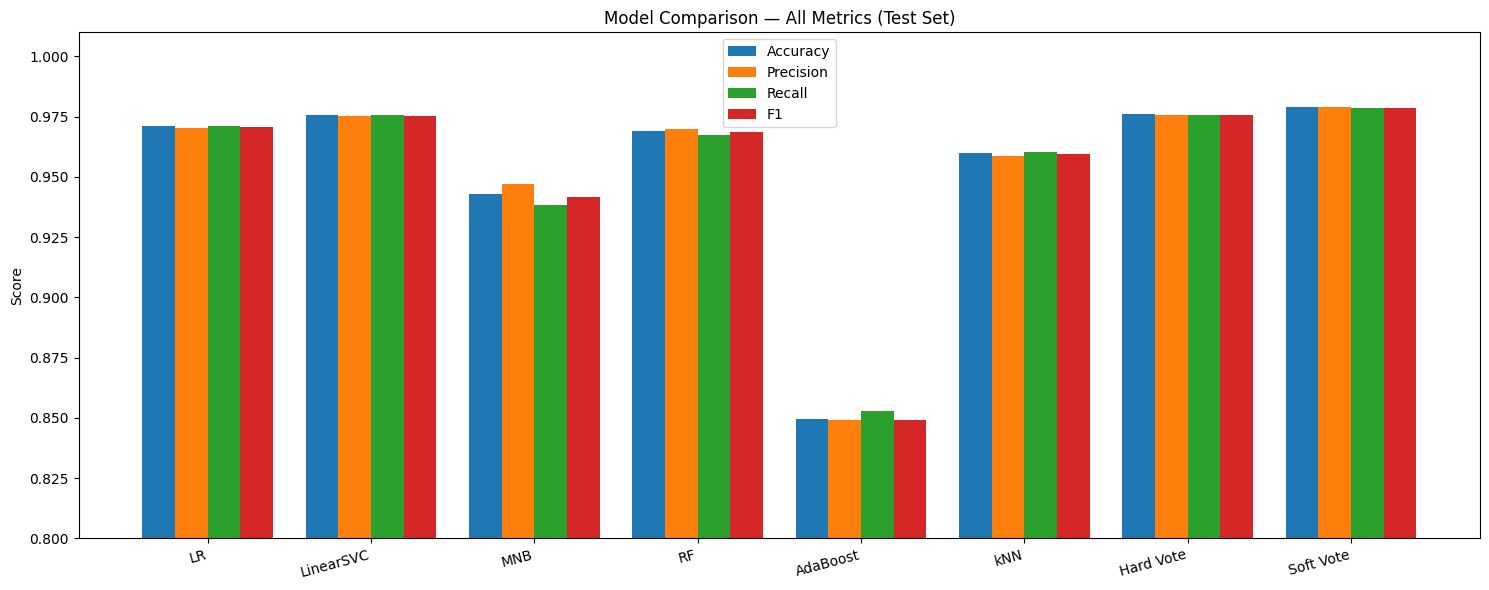

Chart saved.

Model          Accuracy  Precision     Recall         F1
Soft Vote        97.90%     97.90%     97.84%     97.87%
Hard Vote        97.59%     97.56%     97.57%     97.56%
LinearSVC        97.57%     97.52%     97.56%     97.54%
LR               97.10%     97.02%     97.13%     97.07%
RF               96.89%     96.98%     96.75%     96.85%
kNN              95.99%     95.88%     96.05%     95.96%
MNB              94.27%     94.72%     93.84%     94.16%
AdaBoost         84.95%     84.90%     85.28%     84.90%

Key findings:
  Best overall          : Soft Vote (97.87% macro F1)
  Best individual       : LinearSVC (97.54% macro F1)
  Worst model           : AdaBoost (84.90% macro F1)
  Soft vs Hard Vote     : +0.31% F1
  Soft Vote vs LR       : +0.80% F1 gain
  Soft Vote vs LinearSVC: +0.33% F1 gain


In [40]:
# Cell 6.2 — Comparative bar chart + descriptive summary
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs(BASE + 'checkpoints/figures/', exist_ok=True)

metrics     = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names = list(models.keys())
x     = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(15, 6))
for i, metric in enumerate(metrics):
    values = [results[m][metric] for m in model_names]
    ax.bar(x + i * width, values, width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0.80, 1.01)
ax.set_title('Model Comparison — All Metrics (Test Set)')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig(BASE + 'checkpoints/figures/model_comparison.png', dpi=150)
plt.show()
print("Chart saved.")

# Descriptive summary
print("\n" + "=" * 75)
print(f"{'Model':<12} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 75)
for model, row in results_df.iterrows():
    print(f"{model:<12} {row['Accuracy']:>9.2f}% {row['Precision']:>9.2f}% {row['Recall']:>9.2f}% {row['F1']:>9.2f}%")
print("=" * 75)

best             = results_df.index[0]
worst            = results_df.index[-1]
ensemble_soft    = results_df.loc['Soft Vote', 'F1']
ensemble_hard    = results_df.loc['Hard Vote', 'F1']
baseline_lr      = results_df.loc['LR', 'F1']
best_individual  = results_df.drop(['Hard Vote', 'Soft Vote']).index[0]

print("\nKey findings:")
print(f"  Best overall          : {best} ({results_df.loc[best, 'F1']:.2f}% macro F1)")
print(f"  Best individual       : {best_individual} ({results_df.loc[best_individual, 'F1']:.2f}% macro F1)")
print(f"  Worst model           : {worst} ({results_df.loc[worst, 'F1']:.2f}% macro F1)")
print(f"  Soft vs Hard Vote     : {ensemble_soft - ensemble_hard:+.2f}% F1")
print(f"  Soft Vote vs LR       : {ensemble_soft - baseline_lr:+.2f}% F1 gain")
print(f"  Soft Vote vs LinearSVC: {ensemble_soft - results_df.loc['LinearSVC','F1']:+.2f}% F1 gain")

### 6.3 Confusion Matrices

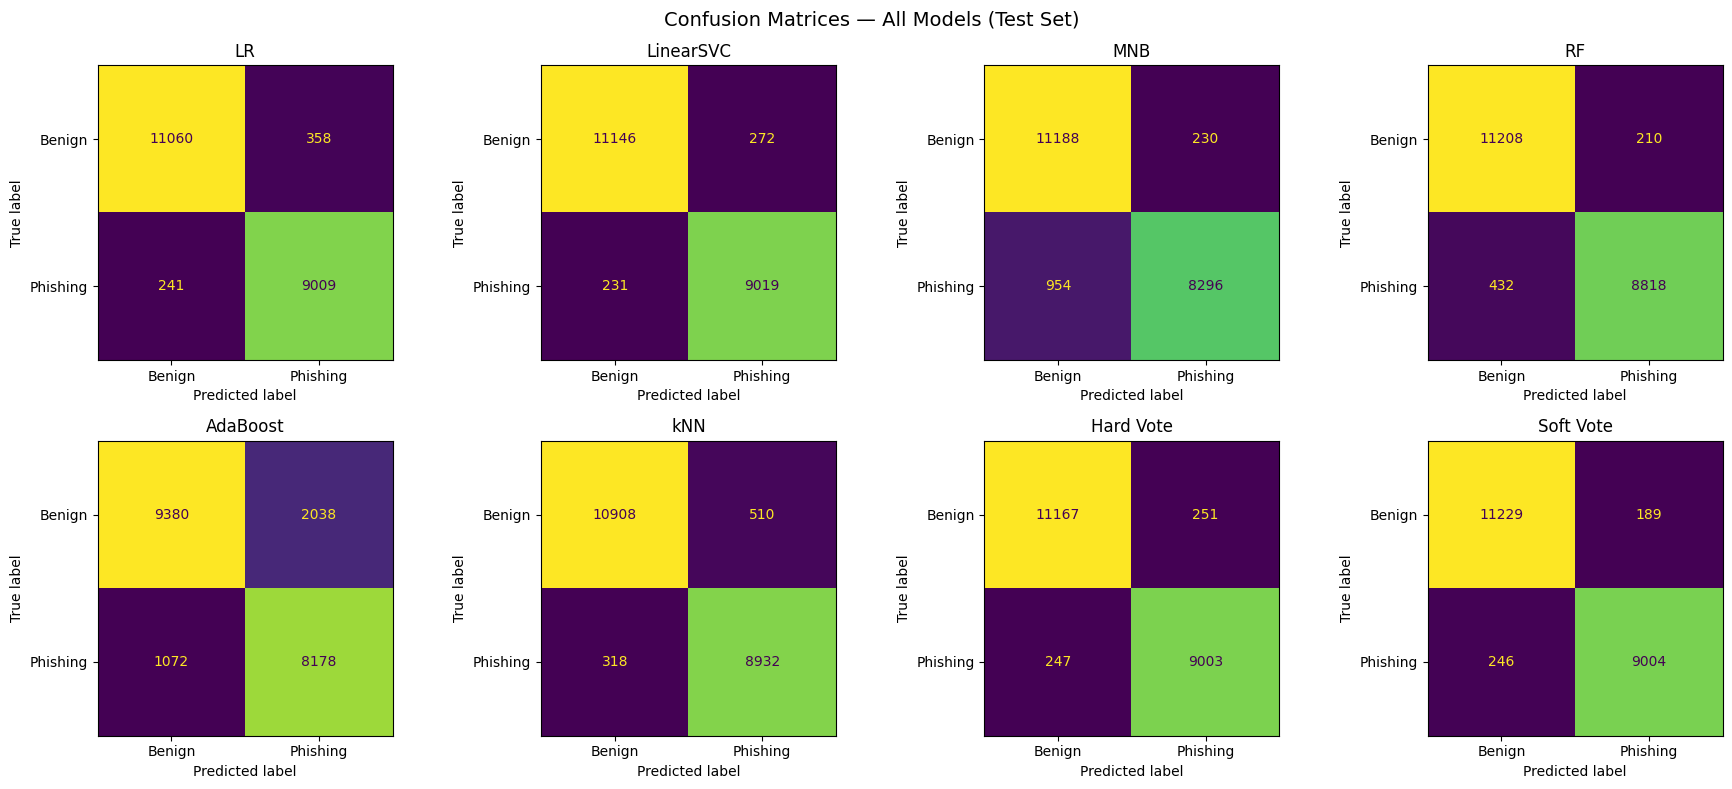

Saved.


In [43]:
# Cell 6.3 — Confusion matrices + descriptive analysis
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (name, preds) in enumerate(models.items()):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Benign', 'Phishing'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)

plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14)
plt.tight_layout()
plt.savefig(BASE + 'checkpoints/figures/confusion_matrices.png', dpi=150)
plt.show()
print("Saved.")


### 6.4 FP / FN Rate Analysis

In a security context, a **False Negative** (missed phishing email) is far more dangerous than a False Positive (legitimate email flagged). We therefore prioritise minimising FN rate alongside macro F1.

In [44]:
# Descriptive analysis
print("\n" + "=" * 75)
print(f"{'Model':<12} {'TN':>8} {'FP':>8} {'FN':>8} {'TP':>8} {'FP Rate':>10} {'FN Rate':>10}")
print("=" * 75)

fn_rates = {}
fp_rates = {}
for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    fp_rate = fp / (fp + tn) * 100
    fn_rate = fn / (fn + tp) * 100
    fp_rates[name] = fp_rate
    fn_rates[name] = fn_rate
    print(f"{name:<12} {tn:>8} {fp:>8} {fn:>8} {tp:>8} {fp_rate:>9.2f}% {fn_rate:>9.2f}%")

print("=" * 75)
print("\n  FP = Benign email wrongly flagged as phishing (annoying but safe)")
print("  FN = Phishing email missed entirely (dangerous)")

best_fn  = min(fn_rates, key=fn_rates.get)
worst_fn = max(fn_rates, key=fn_rates.get)
best_fp  = min(fp_rates, key=fp_rates.get)

print(f"\n  Best FN rate (fewest missed phishing) : {best_fn} ({fn_rates[best_fn]:.2f}%)")
print(f"  Worst FN rate (most missed phishing)  : {worst_fn} ({fn_rates[worst_fn]:.2f}%)")
print(f"  Best FP rate (fewest false alarms)    : {best_fp} ({fp_rates[best_fp]:.2f}%)")


Model              TN       FP       FN       TP    FP Rate    FN Rate
LR              11060      358      241     9009      3.14%      2.61%
LinearSVC       11146      272      231     9019      2.38%      2.50%
MNB             11188      230      954     8296      2.01%     10.31%
RF              11208      210      432     8818      1.84%      4.67%
AdaBoost         9380     2038     1072     8178     17.85%     11.59%
kNN             10908      510      318     8932      4.47%      3.44%
Hard Vote       11167      251      247     9003      2.20%      2.67%
Soft Vote       11229      189      246     9004      1.66%      2.66%

  FP = Benign email wrongly flagged as phishing (annoying but safe)
  FN = Phishing email missed entirely (dangerous)

  Best FN rate (fewest missed phishing) : LinearSVC (2.50%)
  Worst FN rate (most missed phishing)  : AdaBoost (11.59%)
  Best FP rate (fewest false alarms)    : Soft Vote (1.66%)


### 6.5 Precision-Recall Threshold Analysis

For security applications, the decision threshold should be optimised to minimise FN rate. We plot the precision-recall curve and identify the threshold that maximises recall for phishing detection at an acceptable precision.

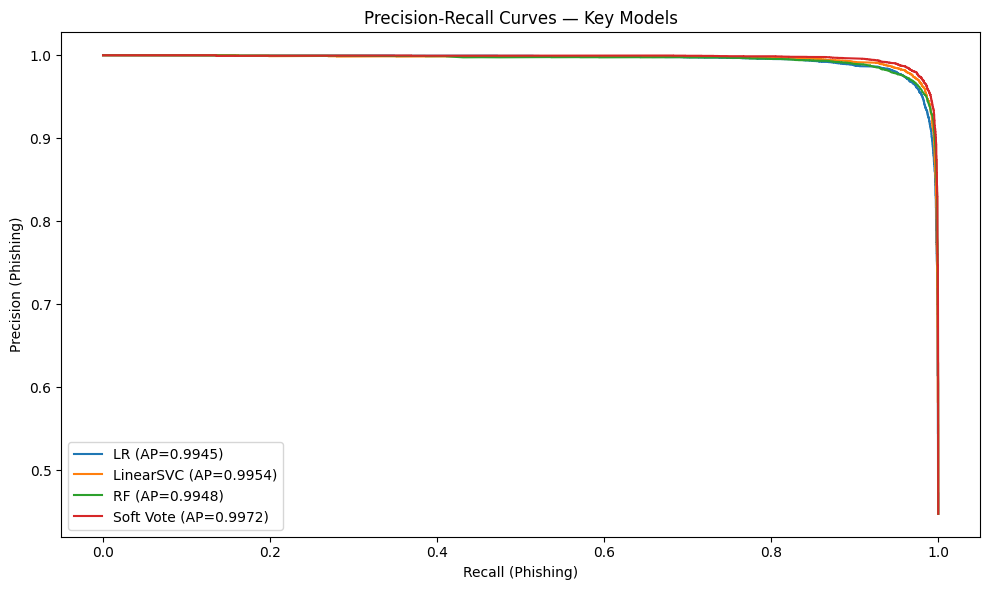

Soft Vote threshold for recall >= 0.98: 0.4517
  Precision at this threshold: 0.9730


In [46]:
# Cell 6.5 — Precision-Recall curve and threshold analysis
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for name, proba_fn in [
    ('LR',        lambda: lr.predict_proba(X_test_tfidf)[:, 1]),
    ('LinearSVC', lambda: svc.predict_proba(X_test_tfidf)[:, 1]),
    ('RF',        lambda: rf.predict_proba(X_test_tfidf)[:, 1]),
    ('Soft Vote', lambda: avg_proba[:, 1])
]:
    proba = proba_fn()
    precision, recall, thresholds = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(recall, precision, label=f'{name} (AP={ap:.4f})')

ax.set_xlabel('Recall (Phishing)')
ax.set_ylabel('Precision (Phishing)')
ax.set_title('Precision-Recall Curves — Key Models')
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig(BASE + 'checkpoints/figures/precision_recall_curves.png', dpi=150)
plt.show()

# Show threshold at recall >= 0.98 for Soft Vote
proba_soft = avg_proba[:, 1]
prec, rec, thresh = precision_recall_curve(y_test, proba_soft)
high_recall_mask = rec[:-1] >= 0.98
if high_recall_mask.any():
    best_thresh = thresh[high_recall_mask][np.argmax(prec[:-1][high_recall_mask])]
    print(f"Soft Vote threshold for recall >= 0.98: {best_thresh:.4f}")
    print(f"  Precision at this threshold: {prec[:-1][high_recall_mask].max():.4f}")

### 6.6 ROC-AUC Curves

Model             AUC
----------------------
LR           0.9954
LinearSVC    0.9964
MNB          0.9913
RF           0.9962
AdaBoost     0.9326
kNN          0.9839
Soft Vote    0.9978


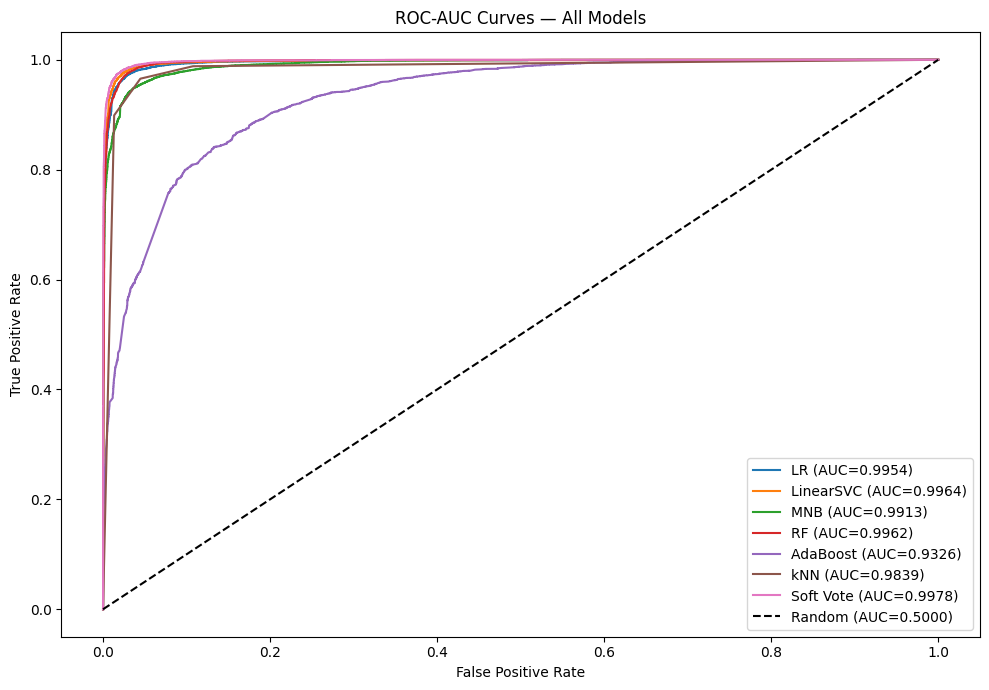

In [48]:
# Cell 6.6 — ROC-AUC curves for all models
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

roc_data = {
    'LR'       : lr.predict_proba(X_test_tfidf)[:, 1],
    'LinearSVC': svc.predict_proba(X_test_tfidf)[:, 1],
    'MNB'      : pipeline_mnb.predict_proba(X_test_tfidf)[:, 1],
    'RF'       : rf.predict_proba(X_test_tfidf)[:, 1],
    'AdaBoost' : pipeline_ada.predict_proba(X_test_tfidf)[:, 1],
    'kNN'      : knn.predict_proba(X_test_tfidf)[:, 1],
    'Soft Vote': avg_proba[:, 1]
}

print(f"{'Model':<12} {'AUC':>8}")
print("-" * 22)
for name, proba in roc_data.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.4f})')
    print(f"{name:<12} {roc_auc:.4f}")

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5000)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-AUC Curves — All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(BASE + 'checkpoints/figures/roc_auc_curves.png', dpi=150)
plt.show()

### 6.7 Statistical Significance — McNemar's Test

McNemar's test determines whether the difference in error rates between two classifiers is statistically significant (p < 0.05). We compare each model against the Soft Vote ensemble.

In [49]:
# Cell 6.7 — McNemar's test: each model vs Soft Vote ensemble
from scipy.stats import chi2

def mcnemar_test(y_true, pred_a, pred_b):
    """McNemar's test — returns chi2 statistic and p-value."""
    b = np.sum((pred_a != y_true) & (pred_b == y_true))  # A wrong, B right
    c = np.sum((pred_a == y_true) & (pred_b != y_true))  # A right, B wrong
    # Continuity-corrected
    stat = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0
    p    = 1 - chi2.cdf(stat, df=1)
    return stat, p, b, c

y_true_np = np.array(y_test)

print(f"{'Model':<12} {'b':>6} {'c':>6} {'chi2':>8} {'p-value':>10} {'Sig?':>6}")
print("-" * 55)
for name, preds in models.items():
    if name == 'Soft Vote':
        continue
    stat, p, b, c = mcnemar_test(y_true_np, np.array(preds), y_pred_soft)
    sig = "YES" if p < 0.05 else "no"
    print(f"{name:<12} {b:>6} {c:>6} {stat:>8.2f} {p:>10.4f} {sig:>6}")

print("\nb = model wrong, Soft Vote right")
print("c = model right, Soft Vote wrong")
print("Sig? = p < 0.05 means Soft Vote is significantly better")

Model             b      c     chi2    p-value   Sig?
-------------------------------------------------------
LR              233     69    87.98     0.0000    YES
LinearSVC       162     94    17.54     0.0000    YES
MNB             833     84   610.15     0.0000    YES
RF              334    127    92.05     0.0000    YES
AdaBoost       2828    153  2398.62     0.0000    YES
kNN             568    175   206.82     0.0000    YES
Hard Vote       108     45    25.12     0.0000    YES

b = model wrong, Soft Vote right
c = model right, Soft Vote wrong
Sig? = p < 0.05 means Soft Vote is significantly better


---
## 7. Leave-One-Source-Out (LOSO) Generalisation Test

LOSO evaluates whether the model generalises to unseen email corpora, not just held-out samples from the same sources. Each source corpus is held out in turn as the test set while all others form the training set. This is a stricter and more realistic evaluation than random splitting.

In [50]:
# Cell 7.1 — LOSO evaluation across all source corpora
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import f1_score
import numpy as np, pandas as pd

sources      = df['source_id'].unique()
loso_results = []

print(f"Running LOSO across {len(sources)} source corpora...")

for held_out in sources:
    print(f"\n--- Held out: {held_out} ---")

    tr_mask = df['source_id'] != held_out
    te_mask = df['source_id'] == held_out

    X_tr, y_tr = df.loc[tr_mask, 'email_text'], df.loc[tr_mask, 'label'].astype(int)
    X_te, y_te = df.loc[te_mask, 'email_text'], df.loc[te_mask, 'label'].astype(int)

    # Fit fresh TF-IDF on this fold's training data only
    tfidf_loso = TfidfVectorizer(
        max_features=20000, ngram_range=(1, 3),
        min_df=5, max_df=0.95,
        stop_words='english', sublinear_tf=True
    )
    X_tr_tfidf = tfidf_loso.fit_transform(X_tr)
    X_te_tfidf = tfidf_loso.transform(X_te)

    clfs = {
        'LR'       : LogisticRegression(class_weight='balanced',
                         C=lr.C, random_state=RANDOM_STATE, max_iter=1000),
        'LinearSVC': CalibratedClassifierCV(LinearSVC(class_weight='balanced',
                         random_state=RANDOM_STATE, max_iter=2000)),
        'MNB'      : ImbPipeline([('ros', RandomOverSampler(random_state=RANDOM_STATE)),
                                   ('clf', MultinomialNB())]),
        'RF'       : RandomForestClassifier(n_estimators=200, class_weight='balanced',
                         random_state=RANDOM_STATE, n_jobs=-1),
        'AdaBoost' : ImbPipeline([('ros', RandomOverSampler(random_state=RANDOM_STATE)),
                                   ('clf', AdaBoostClassifier(random_state=RANDOM_STATE,
                                                              n_estimators=100))]),
        'kNN'      : KNeighborsClassifier(n_neighbors=5, metric='cosine', n_jobs=-1)
    }

    fold_preds  = {}
    fold_probas = []
    for name, clf in clfs.items():
        clf.fit(X_tr_tfidf, y_tr)
        fold_preds[name] = clf.predict(X_te_tfidf)
        f1 = f1_score(y_te, fold_preds[name], average='macro')
        print(f"  {name:<12} F1: {f1:.4f}")
        loso_results.append({'held_out': held_out, 'model': name, 'macro_f1': f1})
        fold_probas.append(clf.predict_proba(X_te_tfidf))

    # Hard vote
    all_p  = np.array(list(fold_preds.values()))
    hard   = np.array([
        fold_preds['LinearSVC'][i] if np.bincount(all_p[:, i].astype(int), minlength=2)[0] ==
                                      np.bincount(all_p[:, i].astype(int), minlength=2)[1]
        else np.argmax(np.bincount(all_p[:, i].astype(int), minlength=2))
        for i in range(all_p.shape[1])
    ])
    f1_hard = f1_score(y_te, hard, average='macro')
    print(f"  {'Hard Vote':<12} F1: {f1_hard:.4f}")
    loso_results.append({'held_out': held_out, 'model': 'Hard Vote', 'macro_f1': f1_hard})

    # Soft vote
    soft   = np.argmax(np.mean(fold_probas, axis=0), axis=1)
    f1_soft = f1_score(y_te, soft, average='macro')
    print(f"  {'Soft Vote':<12} F1: {f1_soft:.4f}")
    loso_results.append({'held_out': held_out, 'model': 'Soft Vote', 'macro_f1': f1_soft})

loso_df = pd.DataFrame(loso_results)
print("\nLOSO evaluation complete.")

Running LOSO across 3 source corpora...

--- Held out: trec5 ---
  LR           F1: 0.7602
  LinearSVC    F1: 0.7924
  MNB          F1: 0.7871
  RF           F1: 0.7598
  AdaBoost     F1: 0.6357
  kNN          F1: 0.6818
  Hard Vote    F1: 0.7844
  Soft Vote    F1: 0.7960

--- Held out: trec6 ---
  LR           F1: 0.7780
  LinearSVC    F1: 0.7545
  MNB          F1: 0.9185
  RF           F1: 0.8403
  AdaBoost     F1: 0.6772
  kNN          F1: 0.7290
  Hard Vote    F1: 0.8060
  Soft Vote    F1: 0.8565

--- Held out: trec7 ---
  LR           F1: 0.9036
  LinearSVC    F1: 0.8865
  MNB          F1: 0.8738
  RF           F1: 0.8108
  AdaBoost     F1: 0.7545
  kNN          F1: 0.7599
  Hard Vote    F1: 0.8978
  Soft Vote    F1: 0.8958

LOSO evaluation complete.


In [51]:
# Cell 7.2 — LOSO results summary table
loso_pivot = loso_df.pivot(index='model', columns='held_out', values='macro_f1')
loso_pivot['mean_F1'] = loso_pivot.mean(axis=1)
loso_pivot['std_F1']  = loso_df.groupby('model')['macro_f1'].std()
loso_pivot = loso_pivot.sort_values('mean_F1', ascending=False)

print("LOSO Macro F1 — per held-out source:")
display((loso_pivot * 100).round(2))

print("\nMean ± Std across all sources:")
for model, row in loso_pivot.iterrows():
    print(f"  {model:<12} {row['mean_F1']*100:.2f}% ± {row['std_F1']*100:.2f}%")

LOSO Macro F1 — per held-out source:


held_out,trec5,trec6,trec7,mean_F1,std_F1
model,,,,,
MNB,78.71,91.85,87.38,85.98,6.68
Soft Vote,79.60,85.65,89.58,84.94,5.03
Hard Vote,78.44,80.60,89.78,82.94,6.02
LR,76.02,77.80,90.36,81.39,7.81
LinearSVC,79.24,75.45,88.65,81.12,6.80
RF,75.98,84.03,81.08,80.36,4.07
kNN,68.18,72.90,75.99,72.36,3.93
AdaBoost,63.57,67.72,75.45,68.91,6.03



Mean ± Std across all sources:
  MNB          85.98% ± 6.68%
  Soft Vote    84.94% ± 5.03%
  Hard Vote    82.94% ± 6.02%
  LR           81.39% ± 7.81%
  LinearSVC    81.12% ± 6.80%
  RF           80.36% ± 4.07%
  kNN          72.36% ± 3.93%
  AdaBoost     68.91% ± 6.03%


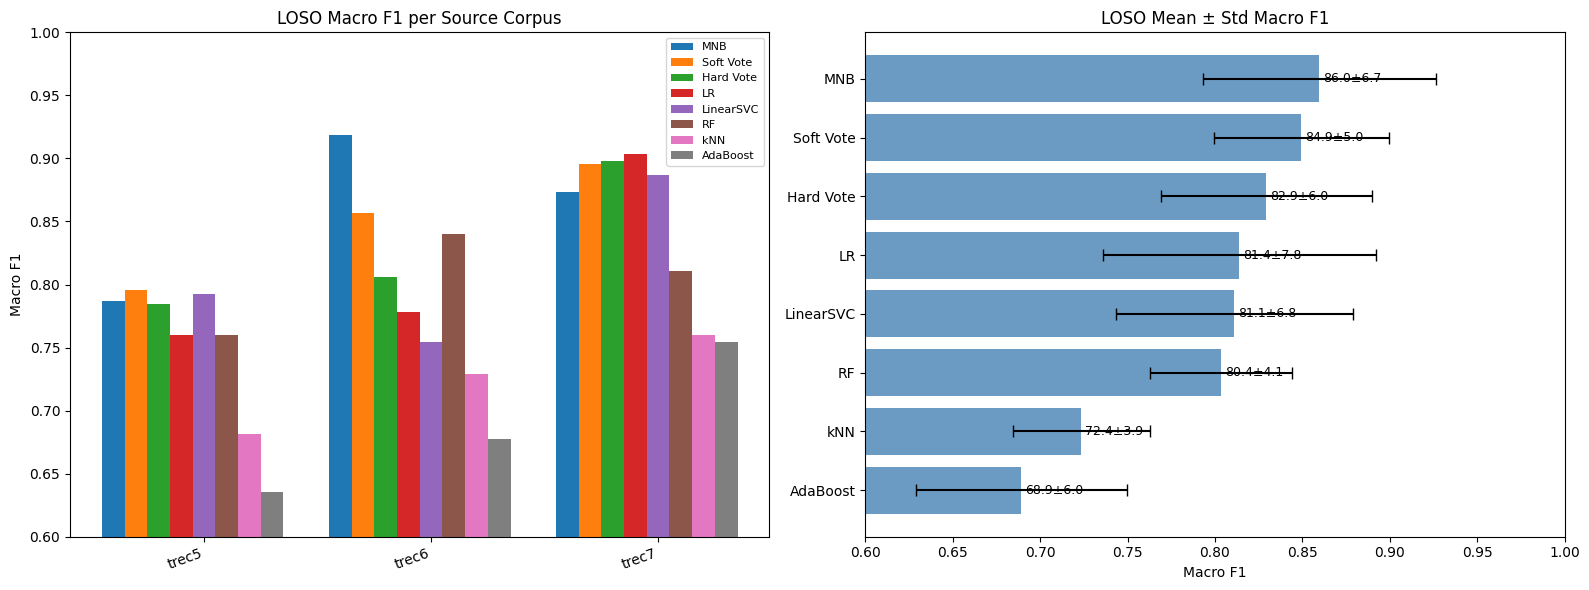

LOSO visualisation saved.


In [59]:
# Cell 7.3 — LOSO results visualisation
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grouped bar chart
model_order  = loso_pivot.index.tolist()
source_order = [c for c in loso_pivot.columns if c not in ['mean_F1', 'std_F1']]
x     = np.arange(len(source_order))
width = 0.8 / len(model_order)

for i, model in enumerate(model_order):
    vals = [loso_pivot.loc[model, src] for src in source_order]
    axes[0].bar(x + i * width, vals, width, label=model)

axes[0].set_xticks(x + width * len(model_order) / 2)
axes[0].set_xticklabels(source_order, rotation=20, ha='right')
axes[0].set_ylim(0.6, 1.0)
axes[0].set_title('LOSO Macro F1 per Source Corpus')
axes[0].set_ylabel('Macro F1')
axes[0].legend(fontsize=8)

# Mean ± std
means = loso_pivot['mean_F1'].values
stds  = loso_pivot['std_F1'].values
axes[1].barh(model_order[::-1], means[::-1], xerr=stds[::-1],
             align='center', capsize=4, color='steelblue', alpha=0.8)
axes[1].set_xlim(0.6, 1.0)
axes[1].set_title('LOSO Mean ± Std Macro F1')
axes[1].set_xlabel('Macro F1')
for i, (m, s) in enumerate(zip(means[::-1], stds[::-1])):
    axes[1].text(m + 0.002, i, f'{m*100:.1f}±{s*100:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(BASE + 'checkpoints/figures/loso_results.png', dpi=150)
plt.show()
print("LOSO visualisation saved.")

---
## 8. Feature Interpretability

Logistic Regression coefficients provide a direct window into which TF-IDF tokens are most predictive of phishing vs legitimate email. Higher positive coefficient → stronger phishing signal; more negative → stronger benign signal.

TOP 20 PHISHING INDICATOR FEATURES
  url                                 +5.3645
  girl                                +4.8897
  pill                                +4.8555
  life                                +4.2409
  offer                               +4.0772
  save                                +4.0503
  emoji                               +3.9876
  loan                                +3.9812
  med                                 +3.9635
  quality                             +3.9142
  men                                 +3.9035
  price                               +3.8430
  medication                          +3.5552
  partner                             +3.3492
  click                               +3.2715
  watch                               +3.2354
  adf                                 +3.0953
  age                                 +2.9720
  mortgage                            +2.9152
  printer                             +2.9106

TOP 20 BENIGN INDICATOR FEATURES
  thanks   

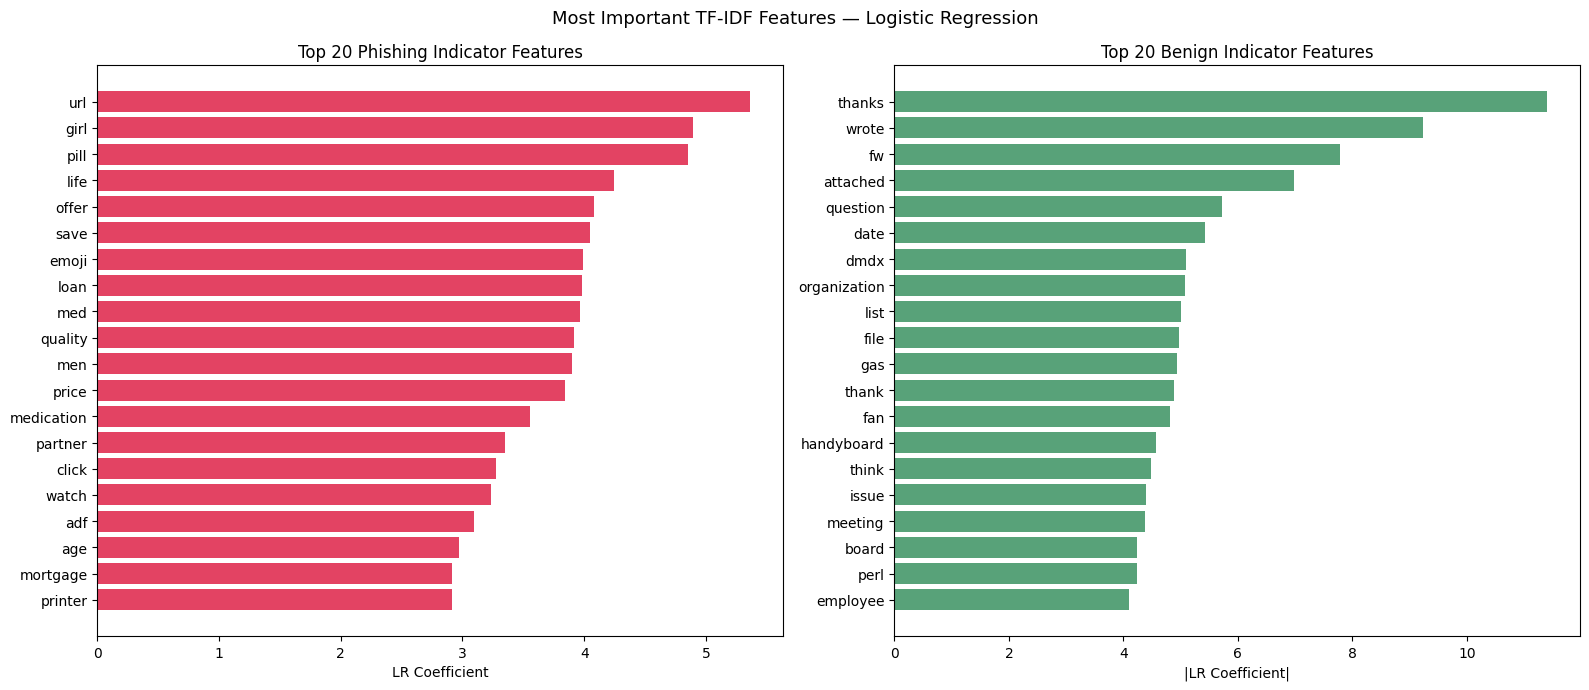

In [53]:
# Cell 8.1 — Top 20 phishing and benign TF-IDF features from Logistic Regression
import numpy as np
import matplotlib.pyplot as plt

feature_names  = np.array(tfidf.get_feature_names_out())
coefficients   = lr.coef_[0]

top_phish_idx  = np.argsort(coefficients)[-20:][::-1]
top_benign_idx = np.argsort(coefficients)[:20]

top_phish_words  = feature_names[top_phish_idx]
top_benign_words = feature_names[top_benign_idx]
top_phish_scores = coefficients[top_phish_idx]
top_benign_scores= coefficients[top_benign_idx]

print("TOP 20 PHISHING INDICATOR FEATURES")
print("=" * 50)
for word, score in zip(top_phish_words, top_phish_scores):
    print(f"  {word:<35} {score:+.4f}")

print("\nTOP 20 BENIGN INDICATOR FEATURES")
print("=" * 50)
for word, score in zip(top_benign_words, top_benign_scores):
    print(f"  {word:<35} {score:+.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.barh(top_phish_words[::-1],  top_phish_scores[::-1],  color='crimson', alpha=0.8)
ax1.set_title('Top 20 Phishing Indicator Features')
ax1.set_xlabel('LR Coefficient')

ax2.barh(top_benign_words[::-1], np.abs(top_benign_scores[::-1]), color='seagreen', alpha=0.8)
ax2.set_title('Top 20 Benign Indicator Features')
ax2.set_xlabel('|LR Coefficient|')

plt.suptitle('Most Important TF-IDF Features — Logistic Regression', fontsize=13)
plt.tight_layout()
plt.savefig(BASE + 'checkpoints/figures/feature_importance.png', dpi=150)
plt.show()

---
## 9. Artifact Persistence

All trained models, the vectoriser, and evaluation outputs

In [70]:
# Cell 9.1 — Save all models, vectoriser and predictions
import joblib, os

# Use fixed checkpoint dir instead of timestamped one
CHECKPOINT_DIR = BASE + 'checkpoints/final/'
os.makedirs(CHECKPOINT_DIR + 'models/', exist_ok=True)
os.makedirs(CHECKPOINT_DIR + 'vectorisers/', exist_ok=True)
os.makedirs(CHECKPOINT_DIR + 'metrics/', exist_ok=True)
os.makedirs(CHECKPOINT_DIR + 'figures/', exist_ok=True)

# Save models
joblib.dump(lr,           CHECKPOINT_DIR + 'models/lr.pkl')
joblib.dump(svc,          CHECKPOINT_DIR + 'models/svc.pkl')
joblib.dump(pipeline_mnb, CHECKPOINT_DIR + 'models/mnb.pkl')
joblib.dump(rf,           CHECKPOINT_DIR + 'models/rf.pkl')
joblib.dump(pipeline_ada, CHECKPOINT_DIR + 'models/ada.pkl')
joblib.dump(knn,          CHECKPOINT_DIR + 'models/knn.pkl')

# Save vectoriser
joblib.dump(tfidf, CHECKPOINT_DIR + 'vectorisers/tfidf.pkl')

# Save processed dataframe
df.to_csv(BASE + 'processed_df.csv', index=False)

# Save split indices
joblib.dump({
    'train': X_train.index.tolist(),
    'test' : X_test.index.tolist()
}, CHECKPOINT_DIR + 'split_indices.pkl')


# Save all predictions
joblib.dump({
    'y_test'     : y_test,
    'y_pred_lr'  : y_pred_lr,
    'y_pred_svc' : y_pred_svc,
    'y_pred_mnb' : y_pred_mnb,
    'y_pred_rf'  : y_pred_rf,
    'y_pred_ada' : y_pred_ada,
    'y_pred_knn' : y_pred_knn,
    'y_pred_hard': y_pred_hard,
    'y_pred_soft': y_pred_soft,
    'avg_proba'  : avg_proba,
    'loso_df'    : loso_df
}, CHECKPOINT_DIR + 'metrics/all_predictions.pkl')

print("All artifacts saved to:")
print(f"  {CHECKPOINT_DIR}")

All artifacts saved to:
  /content/drive/MyDrive/phishing_project/checkpoints/final/


In [5]:
# Cell 9.2 — Final run summary
import pandas as pd
BASE = '/content/drive/MyDrive/phishing_project/'
# Define checkpoint dir
CHECKPOINT_DIR = BASE + 'checkpoints/final/'


print("=" * 60)
print("  PHISHING EMAIL DETECTION — FINAL RUN SUMMARY")
print("=" * 60)
print(f"  Dataset       : MeAJOR ({len(df):,} samples after dedup)")
print(f"  Train / Val / Test : {len(X_train_text):,} / {len(X_val_text):,} / {len(X_test_text):,}")
print(f"  Features      : TF-IDF (20k vocab, 1-3gram)")
print(f"  Models trained: LR, LinearSVC, MNB, RF, AdaBoost, kNN")
print(f"  Ensembles     : Hard Vote, Soft Vote")
print(f"  Tuning        : RandomizedSearchCV (best params applied)")
print(f"  Best model    : (see Cell 6.1 results table)")
print(f"  LOSO best     : (see Cell 7.2 LOSO table)")
print(f"  Checkpoint    : {CHECKPOINT_DIR}")
print("=" * 60)

  PHISHING EMAIL DETECTION — FINAL RUN SUMMARY
  Dataset       : MeAJOR (103,340 samples after dedup)
  Train / Val / Test : 62,004 / 20,668 / 20,668
  Features      : TF-IDF (20k vocab, 1-3gram)
  Models trained: LR, LinearSVC, MNB, RF, AdaBoost, kNN
  Ensembles     : Hard Vote, Soft Vote
  Tuning        : RandomizedSearchCV (best params applied)
  Best model    : (see Cell 6.1 results table)
  LOSO best     : (see Cell 7.2 LOSO table)
  Checkpoint    : /content/drive/MyDrive/phishing_project/checkpoints/final/
